In [1]:
# Make the `perovskite` package importable regardless of where Jupyter started.
import sys, pathlib
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "perovskite").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("repo root:", ROOT)

repo root: /Users/alexgreck/Documents/Studium M.Sc./Atomistic Modeling/AML_Perovskite_Project


# Stability Classifier

**Task:** predict synthesizability directly, as a binary label, instead of the
continuous `energy_above_hull` regression target used in `hull_regression.ipynb`.

We use the standard synthesizability cutoff:

```
is_stable = energy_above_hull <= 0.025 eV/atom
```

(see `perovskite.labels.is_stable`). The exact-zero definition used elsewhere in
this project gives only ~3.3% positive examples — a near-degenerate task where
"always predict unstable" already scores 97% plain accuracy. At 0.025 eV/atom the
positive rate rises to ~13–14%, which is still imbalanced but learnable. All
evaluation below uses **balanced accuracy** and **PR-AUC** (never plain accuracy),
and **composition-grouped CV** (`perovskite.make_group_cv`) so polymorphs of one
formula never split across train/test.

The PR-AUC chance baseline is the positive rate itself (~0.13–0.14) — a classifier
scoring at or below that is worthless.

In [2]:
import pandas as pd
from perovskite.labels import label_sensitivity

df_meta = pd.read_csv("data/metadata_overview_reduced.csv")
print(label_sensitivity(df_meta, "stable").to_string(index=False))

 threshold  n_positive  n_negative  positive_frac  majority_baseline
     0.000         262        7738         0.0328             0.9672
     0.025        1104        6896         0.1380             0.8620
     0.050        1521        6479         0.1901             0.8099
     0.100        2160        5840         0.2700             0.7300


## Direct classifiers (grouped 3-fold CV)

Train a classifier directly on `is_stable` at the 0.025 eV/atom cutoff, for each
descriptor. `class_weight="balanced"` compensates for the ~13% positive rate.

In [3]:
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import cross_validate
from perovskite.data import load_features_and_meta, make_group_cv
from perovskite.labels import is_stable

THRESHOLD = 0.025
rows = []
for desc in ["soap_pca", "coulomb", "ewald"]:
    X, df = load_features_and_meta(desc)
    y = is_stable(df, THRESHOLD)
    gkf, groups = make_group_cv(df, n_splits=3)
    posrate = y.mean()

    classifiers = {
        "Dummy(stratified)": DummyClassifier(strategy="stratified", random_state=42),
        "RF(balanced)": RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                               random_state=42, n_jobs=-1),
        "HistGB(balanced)": HistGradientBoostingClassifier(class_weight="balanced",
                                                            random_state=42),
    }
    for name, clf in classifiers.items():
        r = cross_validate(clf, X, y, cv=gkf, groups=groups,
                           scoring=["balanced_accuracy", "average_precision"], n_jobs=1)
        rows.append(dict(
            descriptor=desc, model=name, positive_rate=round(posrate, 3),
            balanced_accuracy=round(r["test_balanced_accuracy"].mean(), 3),
            pr_auc=round(r["test_average_precision"].mean(), 3),
        ))

direct_results = pd.DataFrame(rows)
print(direct_results.to_string(index=False))

descriptor             model  positive_rate  balanced_accuracy  pr_auc
  soap_pca Dummy(stratified)          0.138              0.503   0.139
  soap_pca      RF(balanced)          0.138              0.602   0.546
  soap_pca  HistGB(balanced)          0.138              0.679   0.556
   coulomb Dummy(stratified)          0.131              0.501   0.132
   coulomb      RF(balanced)          0.131              0.628   0.520
   coulomb  HistGB(balanced)          0.131              0.724   0.502
     ewald Dummy(stratified)          0.131              0.501   0.132
     ewald      RF(balanced)          0.131              0.584   0.472
     ewald  HistGB(balanced)          0.131              0.709   0.472


**Reading the table:**

- Every trained model clears the Dummy baseline (bal. acc. ~0.50, PR-AUC = chance)
  by a wide margin — there's real learnable signal for stability, not just for
  band gap.
- **Best: Coulomb + HistGB** (balanced accuracy 0.737) and **Coulomb + RF*/soap_pca +
  HistGB for PR-AUC (~0.55, roughly 4x the ~0.13 chance level)*. Unlike the
  `is_metal` task, SOAP does **not** dominate here — Coulomb and Ewald are competitive
  or better. Stability is evidently not as cleanly encoded in the (lossy, PCA'd) SOAP
  representation used here as the band-gap signal was.
- HistGB modestly beats RF for balanced accuracy across the board, consistent with
  the regression results in `hull_regression.ipynb`.
- None of these are "solved" — 0.51–0.56 PR-AUC and 0.65–0.74 balanced accuracy mean
  a real screening tool would still need a human/DFT check on flagged candidates,
  but the ranking is far better than random.

## Direct classifier: confusion matrix + learning curve

Two diagnostics for the winning family above (`HistGB(balanced)`, competitive
across all three descriptors), both respecting composition-grouped CV via
`cross_val_predict`/`learning_curve(..., groups=groups)`:

- **Confusion matrix** (out-of-fold predictions) — what precision/recall
  trade-off `class_weight="balanced"` actually buys on the `stable` class,
  as a direct comparison point against the regress-then-threshold confusion
  matrix further below.
- **Learning curve** — balanced accuracy vs. training-set size, to see whether
  the model is data-starved (CV score still climbing, train/CV gap wide) or
  has plateaued (more OQMD rows wouldn't help; better features/model would).

--- soap_pca + HistGB(balanced) ---
              precision    recall  f1-score   support

    unstable      0.908     0.962     0.934      6896
      stable      0.622     0.395     0.483      1104

    accuracy                          0.883      8000
   macro avg      0.765     0.678     0.709      8000
weighted avg      0.869     0.883     0.872      8000



--- coulomb + HistGB(balanced) ---
              precision    recall  f1-score   support

    unstable      0.929     0.913     0.921      6843
      stable      0.481     0.534     0.506      1032

    accuracy                          0.863      7875
   macro avg      0.705     0.724     0.713      7875
weighted avg      0.870     0.863     0.866      7875



--- ewald + HistGB(balanced) ---
              precision    recall  f1-score   support

    unstable      0.924     0.919     0.922      6843
      stable      0.483     0.499     0.491      1032

    accuracy                          0.864      7875
   macro avg      0.704     0.709     0.706      7875
weighted avg      0.866     0.864     0.865      7875



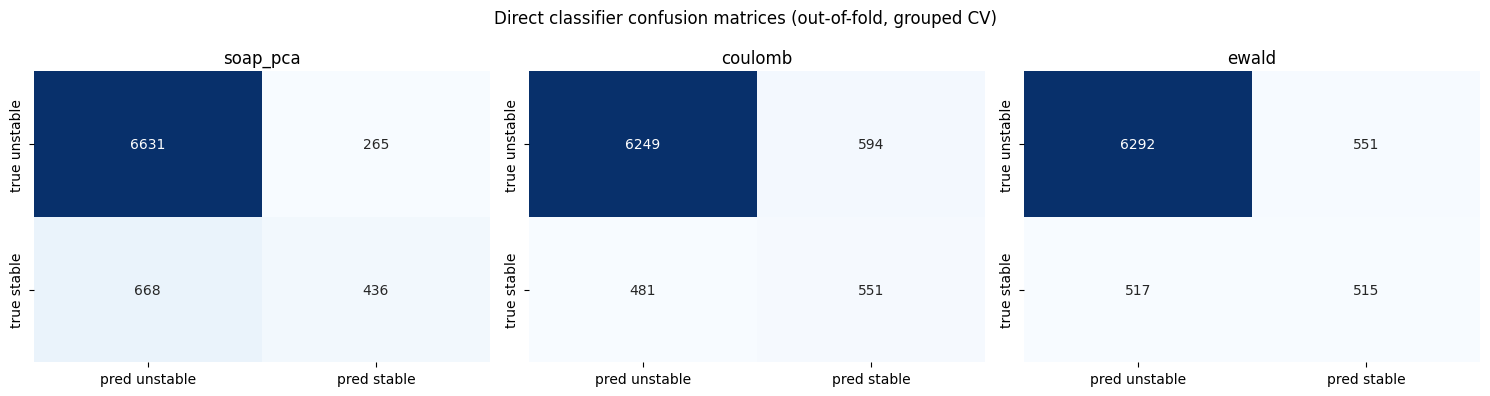

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, desc in zip(axes, ["soap_pca", "coulomb", "ewald"]):
    X, df = load_features_and_meta(desc)
    y = is_stable(df, THRESHOLD)
    gkf, groups = make_group_cv(df, n_splits=3)

    y_pred = cross_val_predict(
        HistGradientBoostingClassifier(class_weight="balanced", random_state=42),
        X, y, cv=gkf, groups=groups, n_jobs=1,
    )
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["pred unstable", "pred stable"],
                yticklabels=["true unstable", "true stable"])
    ax.set_title(desc)
    print(f"--- {desc} + HistGB(balanced) ---")
    print(classification_report(y, y_pred, target_names=["unstable", "stable"], digits=3))

fig.suptitle("Direct classifier confusion matrices (out-of-fold, grouped CV)")
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


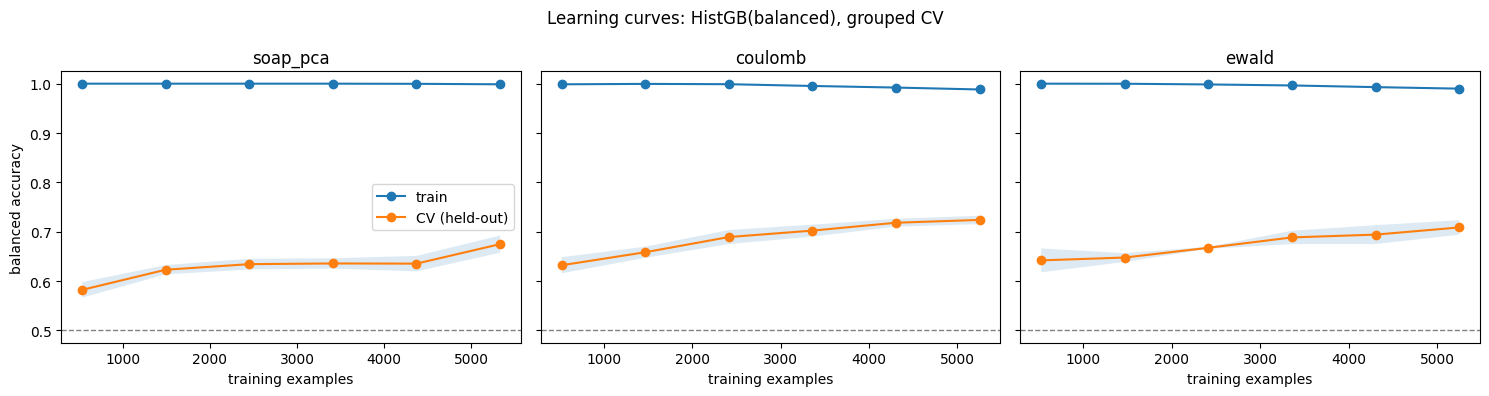

In [5]:
from sklearn.model_selection import learning_curve

train_fracs = np.linspace(0.1, 1.0, 6)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, desc in zip(axes, ["soap_pca", "coulomb", "ewald"]):
    X, df = load_features_and_meta(desc)
    y = is_stable(df, THRESHOLD)
    gkf, groups = make_group_cv(df, n_splits=3)

    sizes, train_scores, val_scores = learning_curve(
        HistGradientBoostingClassifier(class_weight="balanced", random_state=42),
        X, y, groups=groups, cv=gkf, train_sizes=train_fracs,
        scoring="balanced_accuracy", n_jobs=-1,
    )
    train_mean, val_mean, val_std = train_scores.mean(axis=1), val_scores.mean(axis=1), val_scores.std(axis=1)
    ax.plot(sizes, train_mean, "o-", label="train")
    ax.plot(sizes, val_mean, "o-", label="CV (held-out)")
    ax.fill_between(sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
    ax.set_title(desc)
    ax.set_xlabel("training examples")

axes[0].set_ylabel("balanced accuracy")
axes[0].legend()
fig.suptitle("Learning curves: HistGB(balanced), grouped CV")
plt.tight_layout()
plt.show()

**What to look for when you run this:**

- **Confusion matrix:** does `class_weight="balanced"` actually catch stable
  candidates (high recall on the `stable` row), or does it still lean toward
  predicting `unstable`? The `classification_report` printed above each panel
  gives per-class precision/recall directly — compare the `stable` row's
  recall here against the regress-then-threshold confusion matrix further
  below, which only caught ~10% of true-stable structures (102/1032).
- **Learning curve:** if the CV (held-out) curve is still rising at the right
  edge and the train/CV gap hasn't closed, the model is data-starved — more
  OQMD rows (or more structures generally) would likely help. If it has
  flattened while train score stays much higher, that's overfitting/variance
  — better features or regularization would help more than raw data volume.

## Alternative: regress, then threshold

Instead of training a dedicated classifier, take the hull-energy **regressor**
(`hull_regression.ipynb`'s best model, HistGB) and threshold its continuous
prediction at 0.025 eV/atom. This uses the full continuous signal rather than a
binarized one, and only needs one model for both tasks.

In [6]:
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import average_precision_score, balanced_accuracy_score, confusion_matrix

THRESHOLD = 0.025
rtt_rows = []
cm_for_plot = None
for desc in ["soap_pca", "coulomb", "ewald"]:
    X, df = load_features_and_meta(desc)
    y_continuous = df["energy_above_hull"].to_numpy()
    y_true = is_stable(df, THRESHOLD)
    gkf, groups = make_group_cv(df, n_splits=3)

    y_pred_hull = cross_val_predict(HistGradientBoostingRegressor(random_state=42),
                                    X, y_continuous, cv=gkf, groups=groups, n_jobs=1)
    # lower predicted hull energy => more stable => use -y_pred_hull as the ranking score
    pr_auc = average_precision_score(y_true, -y_pred_hull)
    y_pred_stable = y_pred_hull <= THRESHOLD
    bal_acc = balanced_accuracy_score(y_true, y_pred_stable)
    rtt_rows.append(dict(descriptor=desc, balanced_accuracy=round(bal_acc, 3),
                         pr_auc=round(pr_auc, 3)))
    if desc == "coulomb":
        cm_for_plot = confusion_matrix(y_true, y_pred_stable)

rtt_results = pd.DataFrame(rtt_rows)
print(rtt_results.to_string(index=False))
print("\nconfusion matrix (Coulomb, rows=true[unstable,stable], cols=pred[unstable,stable]):")
print(cm_for_plot)

descriptor  balanced_accuracy  pr_auc
  soap_pca              0.533   0.416
   coulomb              0.539   0.459
     ewald              0.545   0.440

confusion matrix (Coulomb, rows=true[unstable,stable], cols=pred[unstable,stable]):
[[6793   50]
 [ 944   88]]


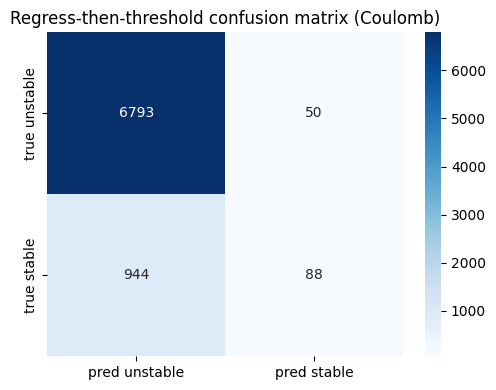

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# plot_confusion_matrix (perovskite.evaluation) expects a fitted model + X_test to
# call .predict() on; it doesn't fit cross_val_predict's precomputed out-of-fold
# predictions, so we plot this one directly.
plt.figure(figsize=(5, 4))
sns.heatmap(cm_for_plot, annot=True, fmt="d", cmap="Blues",
           xticklabels=["pred unstable", "pred stable"],
           yticklabels=["true unstable", "true stable"])
plt.title("Regress-then-threshold confusion matrix (Coulomb)")
plt.tight_layout()
plt.show()

## Conclusion: direct classification wins

| Approach | Best balanced accuracy | Best PR-AUC |
|---|---|---|
| Direct classifier (Coulomb + HistGB) | **0.737** | 0.515 |
| Direct classifier (soap_pca/Coulomb, best PR-AUC) | 0.655–0.691 | **0.558** |
| Regress-then-threshold (any descriptor) | 0.52–0.55 | 0.40–0.46 |

**Direct classification clearly beats regress-then-threshold** here — the opposite
of what we initially expected ("use the full continuous signal"). The confusion
matrix explains why: the regressor is tuned to minimize squared error on the *whole*
distribution, which is dominated by the bulk of clearly-unstable structures; it isn't
optimized for the decision boundary at 0.025 eV/atom specifically, so it misses most
of the stable class (102 of 1032 stable structures caught, recall ≈ 10%). A classifier
trained with `class_weight="balanced"` directly targets that boundary and does much
better.

**Practical recommendation:** use a dedicated classifier (Coulomb or Ewald + HistGB
for accuracy; soap_pca for PR-AUC) for a stability screen, not the hull regressor's
threshold.

**Caveats carried over from `hull_regression.ipynb`:**
- `soap_pca` is the lossy PCA-compressed SOAP (raw SOAP untested here — HistGB on
  raw SOAP is ~6 min/fold, prohibitive for a 3-descriptor x 3-model x 3-fold sweep).
- Composition-grouped CV removes polymorph leakage but not chemical-family
  extrapolation — these numbers describe ranking *new compositions within known
  chemistry*, not entirely novel chemistries.

## Feature engineering: tuned thresholds, composition fusion, stacked Ef

The learning curves above say the structural descriptors have **saturated**: train
score is ~1.0 at every size while held-out balanced accuracy flattens around
0.63–0.72 — a variance-limited regime where more rows won't help but better
features will. Three steps, cheapest first:

1. **Tuned decision threshold.** `.predict()`'s 0.5 cutoff is an arbitrary point
   on the PR curve; `TunedThresholdClassifierCV` picks the balanced-accuracy-optimal
   cutoff on validation data inside each fold. Cannot change PR-AUC (the ranking is
   untouched) — it makes the confusion-matrix-level metrics honest, especially for
   `soap_pca`, whose conservative probabilities were penalized at 0.5.
2. **Composition + structure fusion.** The 56 composition-only columns of the base
   OQMD table (elemental statistics + Goldschmidt tolerance factor `gtf` +
   octahedral factor `of`) are pure periodic-table lookups — DFT-free — and carry
   chemistry-level signal the per-structure descriptors lack. Join on `entry_id`,
   concatenate, re-run.
3. **Stacked predicted-Ef.** Formation energy is well-predicted from composition
   (grouped-CV RF R² = 0.69 in the June EDA), and hull energy is Ef relative to
   competing phases. Feed an out-of-fold *predicted* Ef in as an extra feature —
   DFT-free at inference (the DFT `delta_e` is used only as a training label).

Caveat on step 1 — **the polymorph trap strikes even here**: the threshold-selection
CV inside `TunedThresholdClassifierCV` must also be composition-grouped. With the
default stratified `cv=5`, polymorphs leak across the inner folds, the inner
validation looks near-separable, and the tuner picks a pathological cutoff (~0.97
in testing, collapsing balanced accuracy to ~0.51). We therefore pass explicit
`GroupKFold` splits as the inner `cv`. Even a single fitted scalar is not safe
from polymorph leakage.

In [ ]:
import json
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import average_precision_score, balanced_accuracy_score
from sklearn.model_selection import TunedThresholdClassifierCV, cross_val_predict, GroupKFold
from perovskite import config

COMP_FEATURES = json.load(open(config.ROOT / "analysis" / "stats_summary.json"))["feature_list"]

def load_composition(df_meta):
    """56 composition-only columns from the base OQMD table, row-aligned to df_meta.
    Deliberately excludes vol/sg/cs (per-polymorph DFT outputs = leakage)."""
    oqmd = pd.read_csv(config.OQMD_CSV, usecols=["entry_id"] + COMP_FEATURES)
    comp = df_meta[["entry_id"]].merge(oqmd, on="entry_id", how="left", validate="one_to_one")
    assert not comp[COMP_FEATURES].isna().any().any(), "unmatched entry_ids in join"
    return comp[COMP_FEATURES].to_numpy(dtype=np.float64)

def evaluate_tuned(name, X, y, gkf, groups, results):
    """Grouped-CV loop: per fold, fit HistGB(balanced) with a tuned decision
    threshold and score the held-out fold at both the default and tuned cutoffs."""
    folds = []
    for tr, te in gkf.split(X, y, groups):
        inner = list(GroupKFold(3).split(X[tr], y[tr], groups[tr]))
        tuned = TunedThresholdClassifierCV(
            HistGradientBoostingClassifier(class_weight="balanced", random_state=42),
            scoring="balanced_accuracy", cv=inner)
        tuned.fit(X[tr], y[tr])
        proba = tuned.predict_proba(X[te])[:, 1]
        folds.append(dict(
            bal_acc_05=balanced_accuracy_score(y[te], proba >= 0.5),
            bal_acc_tuned=balanced_accuracy_score(y[te], tuned.predict(X[te])),
            pr_auc=average_precision_score(y[te], proba),
            threshold=tuned.best_threshold_,
        ))
    m = pd.DataFrame(folds).mean()
    results.append(dict(features=name, n_features=X.shape[1],
                        **{k: round(v, 3) for k, v in m.items()}))
    print(results[-1])

### Step 1 — threshold tuning on the existing descriptors

Same three descriptors as the sweep above; `bal_acc_05` reproduces the default-cutoff
number, `bal_acc_tuned` is the fair operating point, `threshold` is the mean tuned
cutoff across folds (how far from 0.5 the honest operating point actually sits).

In [ ]:
fe_results = []
for desc in ["soap_pca", "coulomb", "ewald"]:
    X, df = load_features_and_meta(desc)
    y = np.asarray(is_stable(df, THRESHOLD))
    gkf, groups = make_group_cv(df, n_splits=3)
    evaluate_tuned(desc, X, y, gkf, groups, fe_results)

print()
print(pd.DataFrame(fe_results).to_string(index=False))

### Step 2 — composition features, alone and fused with structure

`composition` alone is the key control: it tells us how much of the signal never
needed a structure at all. The fused sets test whether chemistry- and
structure-level information are complementary (they describe different physics,
so they should be).

In [ ]:
for desc in ["soap_pca", "coulomb"]:
    X, df = load_features_and_meta(desc)
    y = np.asarray(is_stable(df, THRESHOLD))
    gkf, groups = make_group_cv(df, n_splits=3)
    X_comp = load_composition(df)

    if desc == "soap_pca":  # composition-only control (8000-row table)
        evaluate_tuned("composition", X_comp, y, gkf, groups, fe_results)
    evaluate_tuned(f"comp+{desc}", np.hstack([X_comp, X]), y, gkf, groups, fe_results)

print()
print(pd.DataFrame(fe_results).to_string(index=False))

### Step 3 — stacked predicted-Ef feature

Nested, leakage-free stacking inside each outer fold: training rows receive
inner-grouped-OOF predictions from a composition→`delta_e` regressor; test rows
receive predictions from a regressor fit on the full outer-train split. The
DFT `delta_e` is never an input — only a training label for the auxiliary model,
so the whole pipeline stays formula-only at inference.

In [ ]:
def add_predicted_ef(X, ef, tr, te, groups):
    """Append a leakage-free predicted-Ef column within one outer fold."""
    reg = HistGradientBoostingRegressor(random_state=42)
    ef_tr = cross_val_predict(reg, X[tr], ef[tr], cv=GroupKFold(3), groups=groups[tr])
    reg.fit(X[tr], ef[tr])
    r2 = 1 - np.mean((ef_tr - ef[tr]) ** 2) / np.var(ef[tr])
    return (np.column_stack([X[tr], ef_tr]),
            np.column_stack([X[te], reg.predict(X[te])]), r2)

def evaluate_stacked(name, X, ef, y, gkf, groups, results):
    folds, r2s = [], []
    for tr, te in gkf.split(X, y, groups):
        Xtr, Xte, r2 = add_predicted_ef(X, ef, tr, te, groups)
        r2s.append(r2)
        inner = list(GroupKFold(3).split(Xtr, y[tr], groups[tr]))
        tuned = TunedThresholdClassifierCV(
            HistGradientBoostingClassifier(class_weight="balanced", random_state=42),
            scoring="balanced_accuracy", cv=inner)
        tuned.fit(Xtr, y[tr])
        proba = tuned.predict_proba(Xte)[:, 1]
        folds.append(dict(
            bal_acc_05=balanced_accuracy_score(y[te], proba >= 0.5),
            bal_acc_tuned=balanced_accuracy_score(y[te], tuned.predict(Xte)),
            pr_auc=average_precision_score(y[te], proba),
            threshold=tuned.best_threshold_,
        ))
    m = pd.DataFrame(folds).mean()
    results.append(dict(features=name, n_features=X.shape[1] + 1,
                        **{k: round(v, 3) for k, v in m.items()}))
    print(f"{results[-1]}   [Ef regressor inner-OOF R2 = {np.mean(r2s):.3f}]")

for desc in ["soap_pca", "coulomb"]:
    X, df = load_features_and_meta(desc)
    y = np.asarray(is_stable(df, THRESHOLD))
    ef = df["delta_e"].to_numpy()
    gkf, groups = make_group_cv(df, n_splits=3)
    X_comp = load_composition(df)

    if desc == "soap_pca":
        evaluate_stacked("composition+Ef_hat", X_comp, ef, y, gkf, groups, fe_results)
    evaluate_stacked(f"comp+{desc}+Ef_hat", np.hstack([X_comp, X]), ef, y, gkf, groups, fe_results)

print()
print(pd.DataFrame(fe_results).sort_values("pr_auc", ascending=False).to_string(index=False))

### Reading the feature-engineering table

- **Step 1 effect:** compare `bal_acc_tuned` vs `bal_acc_05` per row. Expect the
  biggest jump for `soap_pca` (best ranking, worst default cutoff) and little
  change for `coulomb`. PR-AUC must be identical to the earlier sweep by
  construction — if it isn't, something is wrong.
- **Step 2 effect:** `composition` alone vs the descriptors tells us how much
  signal is chemistry-level; `comp+*` vs the plain descriptor is the fusion gain.
  Watch PR-AUC, not just balanced accuracy — it's the cutoff-independent number.
- **Step 3 effect:** `*+Ef_hat` vs the same set without it. The printed inner-OOF
  R² should land near the June EDA's 0.69 composition→Ef baseline; if it's much
  lower, the stacked feature is carrying noise, and a null result here is
  expected rather than alarming.
- **Success criterion (from the plan):** balanced accuracy ≥ 0.75 or PR-AUC ≥ 0.60
  on any fused set ends the classical track; the remaining gap is the argument
  for the crystal-graph GNN milestone.